# Analytical Noise Schedule: Joint (sigma0, scale) Optimization POC

Runs the analytically derived continuous noise schedule $\sigma(t)$ (recovered from the human forgetting curve) through the full simulation pipeline and jointly optimizes $(\sigma_0, \mathrm{scale})$ against human d' across ISIs.

**Key idea**: Invert $d'(t) = a(t+t_0)^{-\alpha} + d_\infty$ to get $\sigma^2(t) = -2\Delta^2 \dot{d}'(t) / d'(t)^3$, then use this as the per-step noise schedule in the memory model.

Set **`distance_metric`** in the config cell below (default `euclidean`) so $\Delta$, the simulation, and ROC scoring stay consistent; the derivation matches Euclidean geometry in feature space.


In [43]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

from utls.runners_utils import (
    load_experiment_data, compute_human_curve,
    build_encoder, encode_stimuli,
)
from utls.runners_v2 import run_model_core, NoiseSchedule
from utls.toy_experiments import make_high_diversity_sequences
from utls.analysis_helpers import roc_for_isi, auroc_to_dprime
from utls.roc_utils import roc_from_arrays

import types
import sys

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'  # the only attr actually used
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock

plt.rcParams['figure.dpi'] = 120

In [44]:
# --- Distance metric (used everywhere below) ---
# Analytical sigma^2 uses Delta = mean nearest-neighbor *distance* in embedding space;
# the Gaussian derivation is naturally Euclidean. Cosine is kept as an option for comparison.
# Must match a `metric` accepted by `utls.runners_v2.run_model_core`.
distance_metric = 'euclidean'  # e.g. 'euclidean', 'cosine', 'manhattan', 'mahalanobis', 'loglikelihood'
roc_score_type = 'likelihood' if distance_metric == 'loglikelihood' else 'distance'


## Cell 1: Load human data

In [45]:
which_task = 0   # env-sounds (Industrial & Nature)
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

# Target ISIs (exclude ISI=3 which compute_human_curve includes for multi)
target_isis = np.array([0, 1, 2, 4, 8, 16, 32, 64])

# compute_human_curve returns d' for ISIs [0,1,2,3,4,8,16,32,64]
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)
full_isis = np.array([0, 1, 2, 4, 8, 16, 32, 64])
mask = np.isin(full_isis, target_isis)
human_dp = human_curve_full[mask]
isi_values = target_isis

# Compute per-participant d' for SEM
per_subj = []
for run in human_runs:
    row = []
    for isi_val in isi_values:
        res = roc_for_isi(run, isi_val)
        row.append(auroc_to_dprime(res[2]) if res is not None else np.nan)
    per_subj.append(row)
human_dp_mat = np.array(per_subj)
n_valid = np.sum(~np.isnan(human_dp_mat), axis=0)
human_sem = np.nanstd(human_dp_mat, axis=0, ddof=1) / np.sqrt(n_valid)

print(f'Task: {hr_task_name} ({task_name})')
print(f'Participants: {len(human_runs)}')
print(f'ISIs: {isi_values}')
print(f"Human d': {np.round(human_dp, 3)}")
print(f'Human SEM: {np.round(human_sem, 3)}')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Industrial and Nature (env-sounds)
Participants: 104
ISIs: [ 0  1  2  4  8 16 32 64]
Human d': [3.418 3.004 2.435 2.161 1.994 1.886 1.724 1.573]
Human SEM: [0.14  0.13  0.098 0.105 0.094 0.082 0.066 0.081]


## Cell 2: Fit parametric forgetting curve

[ 0  1  2  4  8 16 32 64]
d'(t) = 2.23 * (t + 1.20)^(-0.655) + 1.48
a     = 2.230 +/- 1.301
alpha = 0.655 +/- 0.465
t0    = 1.200 +/- 1.168
d_inf = 1.478 +/- 0.256
R^2   = 0.9833
Implied noise exponent: sigma^2(t) ~ t^(0.309)
[3.45740185 3.17229578 2.97233003 2.82292723 2.70628551 2.61222409
 2.53446252 2.46889769 2.41272556 2.36395898 2.32114694 2.28320299
 2.24929605 2.21877859 2.19113794 2.16596241 2.14291732 2.12172747
 2.10216434 2.08403645 2.06718204 2.05146341 2.03676257 2.02297777
 2.01002075 1.99781454 1.98629172 1.97539289 1.96506558 1.95526316
 1.94594411 1.9370713  1.92861142 1.92053446 1.91281336 1.90542363
 1.89834302 1.89155129 1.88503    1.87876227 1.87273265 1.86692694
 1.86133211 1.85593613 1.85072789 1.84569714 1.84083436 1.83613073
 1.83157807 1.82716874 1.82289564 1.81875213 1.81473204 1.81082956
 1.80703928 1.80335609 1.79977524 1.79629223 1.79290285 1.78960311
 1.78638929 1.78325784 1.78020542 1.77722889 1.77432527 1.77149173
 1.76872559 1.76602432 1.76338552 1.7

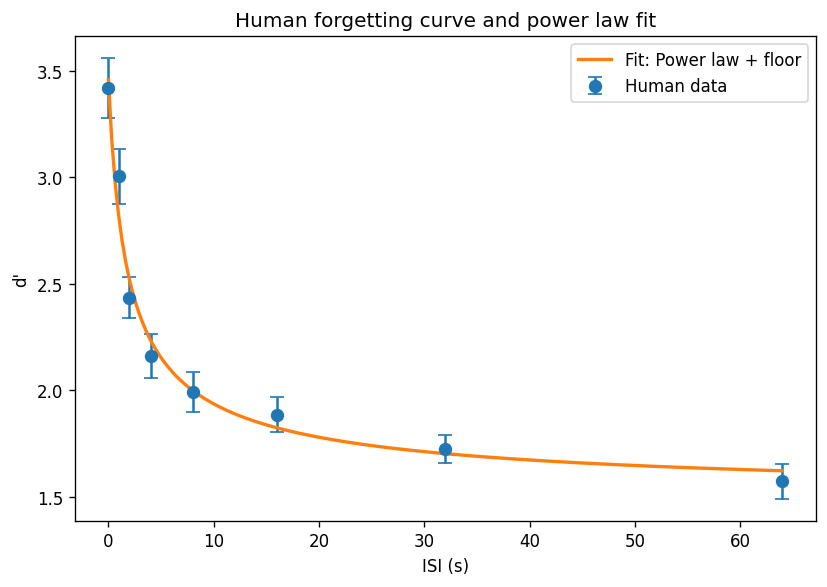

In [46]:
import matplotlib.pyplot as plt

print(isi_values)

def powerlaw_floor(t, a, alpha, t0, d_inf):
    return a * (t + t0) ** (-alpha) + d_inf

def powerlaw_floor_deriv(t, a, alpha, t0, d_inf):
    return -a * alpha * (t + t0) ** (-alpha - 1)


popt, pcov = curve_fit(
    powerlaw_floor, isi_values, human_dp,
    p0=[2.0, 0.3, 1.0, 0.5],
    sigma=human_sem, absolute_sigma=True,
    bounds=([0, 0.01, 0.1, 0], [20, 2.0, 20, 5.0]),
)
a, alpha, t0, d_inf = popt
perr = np.sqrt(np.diag(pcov))

dp_pred = powerlaw_floor(isi_values, *popt)
residuals = human_dp - dp_pred
ss_res = np.sum((residuals / human_sem) ** 2)
ss_tot = np.sum(((human_dp - np.mean(human_dp)) / human_sem) ** 2)
r_sq = 1 - ss_res / ss_tot

print(f"d'(t) = {a:.2f} * (t + {t0:.2f})^(-{alpha:.3f}) + {d_inf:.2f}")
print(f'a     = {a:.3f} +/- {perr[0]:.3f}')
print(f'alpha = {alpha:.3f} +/- {perr[1]:.3f}')
print(f't0    = {t0:.3f} +/- {perr[2]:.3f}')
print(f'd_inf = {d_inf:.3f} +/- {perr[3]:.3f}')
print(f'R^2   = {r_sq:.4f}')
print(f"Implied noise exponent: sigma^2(t) ~ t^({2*alpha - 1:.3f})")

# Plotting human data with fit
isi_plot = np.linspace(0, 64, 200)
fit_curve = powerlaw_floor(isi_plot, *popt)

print(fit_curve)

plt.figure(figsize=(7,5))
plt.errorbar(isi_values, human_dp, yerr=human_sem, fmt='o', label="Human data", capsize=4, color='C0', ms=7)
plt.plot(isi_plot, fit_curve, label="Fit: Power law + floor", color='C1', lw=2)
plt.xlabel("ISI (s)")
plt.ylabel("d'")
plt.title("Human forgetting curve and power law fit")
plt.legend()
plt.tight_layout()
plt.show()

## Cell 3: Build encoder and encode stimuli

In [47]:
encoder_cfg = dict(
    encoder_type='kell2018',
    model_name='kell2018',
    task='word_speaker_audioset',
    layer='relu0',
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=False,
    device='cuda',
)

encoder = build_encoder(encoder_cfg)
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}  (n_stimuli x feature_dim)')
print(f'X0 device: {X0.device}, dtype: {X0.dtype}')

LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/kell2018_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/kell2018_word_audioset_speaker_decay_lr/5728d456-ddc2-4fc2-bf07-a41e658f36d4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/kell2018_word_audioset_speaker_decay_lr/5728d456-ddc2-4fc2-bf07-a41e658f36d4/5_checkpoint.pt' (epoch 6)
X0 shape: torch.Size([80, 886080])  (n_stimuli x feature_dim)
X0 device: cuda:0, dtype: torch.float32


## Cell 4: Compute $\Delta$ (mean nearest-neighbor distance)

Uses `distance_metric` from the config cell: same geometry for the analytical $\Delta$ in $\sigma^2(t)$ and for `run_model_core` scoring.

In [48]:
X0_np = X0.cpu().numpy()


def pairwise_dists_for_delta(X, metric_name):
    """Full pairwise distance matrix (diagonal inf) for mean NND / diagnostics."""
    if metric_name == 'cosine':
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
        d = 1.0 - Xn @ Xn.T
        np.fill_diagonal(d, np.inf)
        return d
    if metric_name == 'euclidean':
        d = squareform(pdist(X, metric='euclidean'))
        np.fill_diagonal(d, np.inf)
        return d
    if metric_name == 'manhattan':
        d = squareform(pdist(X, metric='cityblock'))
        np.fill_diagonal(d, np.inf)
        return d
    if metric_name in ('mahalanobis', 'loglikelihood'):
        # Theory ties Delta to Euclidean feature separation; use Euclidean NND when scoring differs.
        print(f'Note: using Euclidean NND for Delta while distance_metric={metric_name!r}')
        d = squareform(pdist(X, metric='euclidean'))
        np.fill_diagonal(d, np.inf)
        return d
    raise ValueError(
        f'Unsupported distance_metric={metric_name!r}. '
        "Use 'euclidean', 'cosine', 'manhattan', 'mahalanobis', or 'loglikelihood'."
    )


pair_dists = pairwise_dists_for_delta(X0_np, distance_metric)
nn_dists = pair_dists.min(axis=1)
Delta = float(np.mean(nn_dists))

print(f'Delta (mean NND, {distance_metric}) = {Delta:.6f}')
print(f'Median NND = {np.median(nn_dists):.6f}')
print(f'Min NND    = {np.min(nn_dists):.6f}')
print(f'Max NND    = {np.max(nn_dists):.6f}')

d_finite = pair_dists.copy()
d_finite[np.isinf(d_finite)] = np.nan
Delta_mean = float(np.nanmean(d_finite))
print(f'\nMean pairwise ({distance_metric}) dist = {Delta_mean:.6f}')
print(f'Ratio (mean / NND) = {Delta_mean / Delta:.2f}')

Delta (mean NND, euclidean) = 7205.962049
Median NND = 7205.181895
Min NND    = 5754.946652
Max NND    = 10190.123882

Mean pairwise (euclidean) dist = 9032.988611
Ratio (mean / NND) = 1.25


## Cell 5: Define AnalyticalNoiseSchedule

In [49]:
def sigma_sq_analytical_1d(t, fit_params, Delta):
    """1D analytical per-step variance from the fitted d'(t) curve."""
    dp = powerlaw_floor(t, *fit_params)
    dp_dot = powerlaw_floor_deriv(t, *fit_params)
    return -2 * Delta**2 * dp_dot / dp**3


class AnalyticalNoiseSchedule(NoiseSchedule):
    """
    Noise schedule derived from inverting a parametric d'(t) curve.

    Given d'(t) = a(t + t0)^(-alpha) + d_inf, the per-step noise variance
    in a 1D idealized model is:

        sigma^2_1D(t) = -2 * Delta^2 * d'_dot(t) / d'(t)^3

    In run_model_core, drift is applied as:
        noise = randn(D) * (std * scaled_std)
    where ||scaled_std||^2 = D. So Euclidean variance per step is std^2 * D,
    requiring std(t)^2 = sigma^2_1D(t) / D.
    """

    def __init__(self, fit_params, Delta, feat_dim, rms_std=None, scale=1.0):
        self.fit_params = fit_params
        self.Delta = Delta
        self.D = feat_dim
        self.rms_std = rms_std
        self.scale = scale

    def __call__(self, age):
        if age <= 0:
            return 1e-10

        t = float(age)
        ssq_1d = sigma_sq_analytical_1d(t, self.fit_params, self.Delta)
        ssq_1d = max(ssq_1d, 0.0)

        # Correct 1D variance to simulation units (D-dimensional drift).
        ssq_sim = ssq_1d / self.D

        # Optional hook: encoding/drift unit mismatch correction if needed.
        ssq_sim = max(ssq_sim, 1e-40)
        return max(self.scale * np.sqrt(ssq_sim), 1e-10)


# Quick sanity check: print schedule values at a few ages
D = X0.shape[1]
rms_std_val = float(torch.sqrt(torch.mean(X0.std(0, unbiased=True) ** 2)))

test_sched = AnalyticalNoiseSchedule(
    fit_params=popt, Delta=Delta, feat_dim=D, rms_std=rms_std_val, scale=1.0,
)
for age in [1, 2, 4, 8, 16, 32, 64]:
    print(f'  age={age:3d} (ISI={age-1:2d}): sigma = {test_sched(age):.6f}')


  age=  1 (ISI= 0): sigma = 1.447594
  age=  2 (ISI= 1): sigma = 1.249934
  age=  4 (ISI= 3): sigma = 1.000546
  age=  8 (ISI= 7): sigma = 0.737885
  age= 16 (ISI=15): sigma = 0.504616
  age= 32 (ISI=31): sigma = 0.324674
  age= 64 (ISI=63): sigma = 0.199741


## Cell 6: Calibrate sigma0 (old — for reference, optional)

Find `sigma0_model` so that model d' at ISI=0 matches human d'(0).
This short calibration with near-zero diffusion noise is retained for diagnostics, but the main fit below uses joint optimization over `(sigma0, scale)` on full experiment sequences.


In [50]:
from utls.runners_v2 import NoiseSchedule as _NS

class NearZeroSchedule(_NS):
    def __call__(self, age):
        return 1e-10

# Generate a small set of sequences for calibration
cal_isi_values = [0]
cal_sequences, _ = make_high_diversity_sequences(
    stimulus_pool=all_files,
    isi_values=cal_isi_values,
    n_sequences=8,
    length=60,
    min_pairs_per_isi=5,
    seed=99,
)

def eval_dprime_at_isi0(sigma0_test, n_mc=3):
    near_zero = NearZeroSchedule()
    runner_isi = 1  # ISI=0 in experiment -> age=1 in model
    all_hits, all_fas = [], []
    for rep in range(n_mc):
        run = run_model_core(
            sigma0=sigma0_test, X0=X0, name_to_idx=name_to_idx,
            experiment_list=cal_sequences, noise_schedule=near_zero,
            metric=distance_metric, seed=99 * 10_000 + rep,
        )
        all_hits.extend(run['isi_hit_dists'].get(runner_isi, []))
        all_fas.extend(run['fas'])
    if len(all_hits) < 3:
        return np.nan
    hits_scores = np.array([s for s, t in all_hits], dtype=float)
    fas_arr = np.array(all_fas, dtype=float)
    roc = roc_from_arrays(hits_scores, fas_arr, score_type=roc_score_type)
    if roc is None:
        return np.nan
    _, _, auc_val = roc
    return auroc_to_dprime(auc_val)

# Binary search for sigma0
target_dp0 = human_dp[0]
lo, hi = 0.0, Delta*2
print(f"Target d\'(ISI=0) = {target_dp0:.3f}")
print('Calibrating sigma0...')

for _ in range(15):
    mid = (lo + hi) / 2
    dp = eval_dprime_at_isi0(mid)
    print(f"  sigma0={mid:.4f} -> d\'={dp:.3f}")
    if np.isnan(dp) or dp > target_dp0:
        lo = mid  # need more noise to lower d'
    else:
        hi = mid

sigma0_model = (lo + hi) / 2
print(f"\nCalibrated sigma0_model = {sigma0_model:.4f}")

Aggregate ISI usage across all sequences:
  ISI -1: 160
  ISI 0: 320
Target d'(ISI=0) = 3.418
Calibrating sigma0...
  sigma0=7205.9620 -> d'=0.017
  sigma0=3602.9810 -> d'=0.017
  sigma0=1801.4905 -> d'=0.017
  sigma0=900.7453 -> d'=0.017
  sigma0=450.3726 -> d'=0.018
  sigma0=225.1863 -> d'=0.018
  sigma0=112.5932 -> d'=0.022
  sigma0=56.2966 -> d'=0.038
  sigma0=28.1483 -> d'=0.179
  sigma0=14.0741 -> d'=1.720
  sigma0=7.0371 -> d'=6.490
  sigma0=10.5556 -> d'=3.544
  sigma0=12.3149 -> d'=2.518
  sigma0=11.4352 -> d'=2.997
  sigma0=10.9954 -> d'=3.260

Calibrated sigma0_model = 10.7755


In [51]:
# Diagnostic: check encoding variance consistency with d'(ISI=0)
V_enc = sigma0_model**2 * D * (rms_std_val**2)
expected_V0 = Delta**2 / (human_dp[0]**2)
print(f"V_enc = {V_enc:.2f}")
print(f"Delta^2 / d'(0)^2 = {expected_V0:.2f}")
print(f"Ratio V_enc / expected = {V_enc / expected_V0:.4f}")


V_enc = 4792805788.38
Delta^2 / d'(0)^2 = 4443913.63
Ratio V_enc / expected = 1078.5101


## Cell 7: Generate experiment sequences

In [ ]:
experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=all_files,
    isi_values=list(isi_values),
    n_sequences=100,
    length=120,
    min_pairs_per_isi=4,
    seed=42,
)
runner_isi_values = [isi + 1 for isi in isi_values]
print(f'{len(experiment_list)} sequences, length {len(experiment_list[0])}')
print(f'runner_isi_values = {runner_isi_values}')


## Cell 8: Joint (sigma0, scale) optimization

In [ ]:
def compute_model_dprime_curve(sigma0_val, scale_val, n_mc=1, seed=42):
    """Run the full simulation and return model d' at each ISI."""
    schedule = AnalyticalNoiseSchedule(
        fit_params=popt, Delta=Delta, feat_dim=D,
        rms_std=rms_std_val, scale=scale_val,
    )

    agg_isi_hits = defaultdict(list)
    agg_fas = []

    for rep in range(n_mc):
        run = run_model_core(
            sigma0=sigma0_val, X0=X0, name_to_idx=name_to_idx,
            experiment_list=experiment_list, noise_schedule=schedule,
            metric=distance_metric, seed=seed * 10_000 + rep,
        )
        for risi in runner_isi_values:
            agg_isi_hits[risi].extend(run['isi_hit_dists'].get(risi, []))
        agg_fas.extend(run['fas'])

    fas_arr = np.array(agg_fas, dtype=float)
    dp_arr = np.full(len(isi_values), np.nan)
    for i, (exp_isi, risi) in enumerate(zip(isi_values, runner_isi_values)):
        hits_raw = agg_isi_hits.get(risi, [])
        if len(hits_raw) < 3:
            continue
        hits_scores = np.array([s for s, t in hits_raw], dtype=float)
        roc = roc_from_arrays(hits_scores, fas_arr, score_type=roc_score_type)
        if roc is not None:
            dp_arr[i] = auroc_to_dprime(roc[2])
    return dp_arr


def joint_mse(sigma0_val, scale_val, n_mc=1, seed=42):
    """Compute MSE between model and human d' curves."""
    dp_arr = compute_model_dprime_curve(sigma0_val, scale_val, n_mc=n_mc, seed=seed)
    return float(np.nanmean((dp_arr - human_dp) ** 2))


In [ ]:
# --- Coarse grid search ---
sigma0_grid = np.linspace(5, 30, 6)
scale_grid = np.geomspace(0.5, 5.0, 8)

grid_results = {}
for s0 in sigma0_grid:
    for sc in scale_grid:
        mse = joint_mse(s0, sc, n_mc=1, seed=42)
        grid_results[(s0, sc)] = mse
        print(f"  sigma0={s0:.2f}, scale={sc:.2f} -> MSE={mse:.4f}")

best_key = min(grid_results, key=grid_results.get)
best_s0_coarse, best_sc_coarse = best_key
print(
    f"\nCoarse best: sigma0={best_s0_coarse:.4f}, scale={best_sc_coarse:.4f}, "
    f"MSE={grid_results[best_key]:.4f}"
)


In [ ]:
# --- Fine grid around coarse optimum ---
sigma0_fine = np.linspace(best_s0_coarse * 0.7, best_s0_coarse * 1.3, 8)
scale_fine = np.geomspace(best_sc_coarse * 0.7, best_sc_coarse * 1.3, 8)

fine_results = {}
for s0 in sigma0_fine:
    for sc in scale_fine:
        mse = joint_mse(s0, sc, n_mc=1, seed=42)
        fine_results[(s0, sc)] = mse
        print(f"  sigma0={s0:.2f}, scale={sc:.2f} -> MSE={mse:.4f}")

best_key_fine = min(fine_results, key=fine_results.get)
best_s0_fine, best_sc_fine = best_key_fine
print(
    f"\nFine best: sigma0={best_s0_fine:.4f}, scale={best_sc_fine:.4f}, "
    f"MSE={fine_results[best_key_fine]:.4f}"
)


In [ ]:
from scipy.optimize import minimize

run_nelder_mead = False
if run_nelder_mead:
    def objective_for_scipy(params):
        s0, sc = params
        if s0 <= 0 or sc <= 0:
            return 100.0
        return joint_mse(s0, sc, n_mc=1, seed=42)

    result = minimize(
        objective_for_scipy,
        x0=[best_s0_fine, best_sc_fine],
        method='Nelder-Mead',
        options={'xatol': 0.1, 'fatol': 0.01, 'maxiter': 50},
    )
    best_s0_opt, best_sc_opt = result.x
    print(f"Optimized: sigma0={best_s0_opt:.4f}, scale={best_sc_opt:.4f}, MSE={result.fun:.4f}")
else:
    best_s0_opt, best_sc_opt = best_s0_fine, best_sc_fine
    print('Skipping Nelder-Mead; using fine-grid optimum.')


In [ ]:
sigma0_final = best_s0_opt
scale_final = best_sc_opt

final_dp = compute_model_dprime_curve(sigma0_final, scale_final, n_mc=5, seed=42)
final_mse = float(np.nanmean((final_dp - human_dp) ** 2))

print(f"Final sigma0 = {sigma0_final:.4f}")
print(f"Final scale  = {scale_final:.4f}")
print(f"Model d':  {np.round(final_dp, 3)}")
print(f"Human d':  {np.round(human_dp, 3)}")
print(f"MSE = {final_mse:.4f}")


In [ ]:
best_schedule_final = AnalyticalNoiseSchedule(
    fit_params=popt, Delta=Delta, feat_dim=D,
    rms_std=rms_std_val, scale=scale_final,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel A: d' vs ISI
ax = axes[0]
ax.errorbar(isi_values, human_dp, yerr=human_sem,
            fmt='ko', capsize=3, markersize=5, label='Human', zorder=3)
ax.plot(isi_values, final_dp, 'bs-', markersize=5, lw=2,
        label=f"Model (σ₀={sigma0_final:.1f}, scale={scale_final:.2f})")
ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('A. Forgetting curves')
ax.legend()
ax.set_ylim(bottom=0)

# Panel B: noise schedule
ax = axes[1]
ages = np.arange(1, 70)
vals = [best_schedule_final(a) for a in ages]
ax.plot(ages - 1, vals, 'b-', lw=2)
ax.set_xlabel('ISI')
ax.set_ylabel('σ(t) per step')
ax.set_title('B. Analytical noise schedule')
ax.set_ylim(bottom=0)

# Panel C: MSE landscape (fine grid)
ax = axes[2]
s0_vals = sorted(set(k[0] for k in fine_results))
sc_vals = sorted(set(k[1] for k in fine_results))
mse_grid = np.array([[fine_results.get((s0, sc), np.nan)
                      for sc in sc_vals] for s0 in s0_vals])
im = ax.pcolormesh(sc_vals, s0_vals, mse_grid, shading='auto', cmap='viridis')
ax.plot(scale_final, sigma0_final, 'r*', markersize=15, label='Best')
ax.set_xlabel('scale')
ax.set_ylabel('sigma0')
ax.set_title('C. MSE landscape')
plt.colorbar(im, ax=ax, label='MSE')
ax.legend()

plt.tight_layout()
plt.savefig('analytical_schedule_joint_opt.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
print('=' * 60)
print('JOINT OPTIMIZATION SUMMARY')
print('=' * 60)
print(f'Feature dim D      = {D}')
print(f'Delta (mean NND)   = {Delta:.4f}')
print(f'Fit: a={a:.3f}, alpha={alpha:.3f}, t0={t0:.3f}, d_inf={d_inf:.3f}')
print(f'sigma0 (final)     = {sigma0_final:.4f}')
print(f'scale (final)      = {scale_final:.4f}')
print(f'MSE                = {final_mse:.4f}')
print(f"Model d': {np.round(final_dp, 3)}")
print(f"Human d': {np.round(human_dp, 3)}")
print('=' * 60)


## Cell 9: Bootstrap sensitivity

In [ ]:
# Bootstrap sensitivity of analytical schedule shape given fixed optimized sigma0/scale
n_boot = 200
schedule_boot = []

if 'human_runs' in globals() and 'per_subj' in globals() and len(per_subj) > 0:
    per_subj_arr = np.array(per_subj)
    for _ in range(n_boot):
        idx = np.random.choice(len(per_subj_arr), len(per_subj_arr), replace=True)
        boot_dp = np.nanmean(per_subj_arr[idx], axis=0)
        try:
            popt_b, _ = curve_fit(
                powerlaw_floor, isi_values, boot_dp, p0=popt, bounds=bounds
            )
            sched_b = AnalyticalNoiseSchedule(
                popt_b, Delta, feat_dim=D, rms_std=rms_std_val, scale=scale_final
            )
            schedule_boot.append([sched_b(a) for a in range(1, 65)])
        except Exception:
            continue

    schedule_boot = np.array(schedule_boot)
    if len(schedule_boot) > 0:
        x = np.arange(1, 65)
        plt.figure(figsize=(8, 4.5))
        plt.fill_between(
            x,
            np.percentile(schedule_boot, 2.5, axis=0),
            np.percentile(schedule_boot, 97.5, axis=0),
            alpha=0.25,
            label='95% bootstrap CI',
        )
        plt.plot(x, np.median(schedule_boot, axis=0), lw=2, label='Bootstrap median')
        plt.xlabel('age (runner ISI + 1)')
        plt.ylabel('sigma(t) per step')
        plt.title('Bootstrap uncertainty of analytical schedule')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('Bootstrap produced no successful fits; skipping plot.')
else:
    print("Missing 'human_runs'/'per_subj' in notebook context; skipping bootstrap cell.")
